# Imports

In [4]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [5]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/hojjatk/mnist-dataset/train-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte


# Data Handling


In [6]:
!pip install idx2numpy
import idx2numpy
base_path = '/kaggle/input/datasets/hojjatk/mnist-dataset'

# Load the files directly
train_images = idx2numpy.convert_from_file(f'{base_path}/train-images.idx3-ubyte')
train_labels = idx2numpy.convert_from_file(f'{base_path}/train-labels.idx1-ubyte')
test_images = idx2numpy.convert_from_file(f'{base_path}/t10k-images.idx3-ubyte')
test_labels = idx2numpy.convert_from_file(f'{base_path}/t10k-labels.idx1-ubyte')

# Flatten images from 28x28 to 784
train_images = train_images.reshape(train_images.shape[0], -1)
test_images = test_images.reshape(test_images.shape[0], -1)

# Combine into one DataFrame
all_images = np.concatenate([train_images, test_images], axis=0)
all_labels = np.concatenate([train_labels, test_labels], axis=0)

df = pd.DataFrame(all_images, columns=[f'pixel{i}' for i in range(784)])
df.insert(0, 'label', all_labels)

  Preparing metadata (setup.py) ... done
  Created wheel for idx2numpy: filename=idx2numpy-1.2.3-py3-none-any.whl size=7903 sha256=03752c2a2d0861e3b155d618111f64ecbb02b3176c1493322ee7eeb4456c80bc
  Stored in directory: /root/.cache/pip/wheels/f7/48/00/ae031c97d62f39e1c3c4daa00426c09a65eb29ae5753a189ee
Successfully built idx2numpy


In [7]:
df.shape

(70000, 785)

In [8]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df[['label']].value_counts()

label
1        7877
7        7293
3        7141
2        6990
9        6958
0        6903
6        6876
8        6825
4        6824
5        6313
Name: count, dtype: int64

In [10]:
X = df.drop('label', axis=1).values
y = df['label'].values  

In [11]:
# 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=12, stratify=y
)

# split the 40% into 20% validation and 20% test (50/50 of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=12, stratify=y_temp
)

In [12]:
print(f"train: {X_train.shape}")
print(f"val:   {X_val.shape}")
print(f"test:  {X_test.shape}")

train: (42000, 784)
val:   (14000, 784)
test:  (14000, 784)


In [13]:
# convert numpy arrays to PyTorch tensors
# normalize pixel values from 0-255 to 0-1
X_train_tensor = torch.FloatTensor(X_train) / 255.0
y_train_tensor = torch.LongTensor(y_train)

X_val_tensor = torch.FloatTensor(X_val) / 255.0
y_val_tensor = torch.LongTensor(y_val)

X_test_tensor = torch.FloatTensor(X_test) / 255.0
y_test_tensor = torch.LongTensor(y_test)

In [14]:
# create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [15]:
# create DataLoaders
batch_size = 80
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

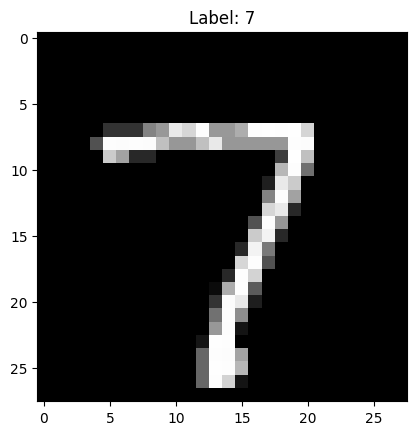

In [16]:
# test
image, label = train_dataset[512]
image_2d = image.reshape(28, 28)
plt.imshow(image_2d, cmap='gray')
plt.title(f"Label: {label.item()}")
plt.show()

# Neural Network Architecture

 The input is a flattened 28×28 image (784 pixels), and the output is 10 logits, one per digit.

```
784 → 512 → 256 → 128 → 10
```

In [17]:
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

class MNISTNet(nn.Module):
  
    def __init__(self, input_size=784, hidden_sizes=[512, 256, 128], num_classes=10):
        super(MNISTNet, self).__init__()
        layers = []
        in_features = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.ReLU())
            in_features = h
        layers.append(nn.Linear(in_features, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


model = MNISTNet().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

Using device: cpu
MNISTNet(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 567,434


# Training Loop


Custom training loop using:
- **Optimizer**: SGD (Stochastic Gradient Descent)
- **Learning Rate**: 0.01
- **Loss Function**: CrossEntropyLoss
- **Epochs**: 20

In [18]:
import torch.optim as optim

def train_model(model, train_loader, val_loader,
                num_epochs=20, learning_rate=0.01):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  []
    }

    for epoch in range(1, num_epochs + 1):

        #  Training phase 
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()                      #  Clear gradients
            outputs = model(images)                    #  Forward pass
            loss    = criterion(outputs, labels)       #  Compute loss
            loss.backward()                            #  Backprop
            optimizer.step()                           #  Update weights

            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc  = 100.0 * correct / total

        #  Validation phase 
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)

                val_loss_sum += loss.item() * images.size(0)
                _, predicted  = torch.max(outputs, 1)
                val_total    += labels.size(0)
                val_correct  += (predicted == labels).sum().item()

        val_loss = val_loss_sum / val_total
        val_acc  = 100.0 * val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch [{epoch:>2}/{num_epochs}]  '
                  f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  '
                  f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%')

    return history

In [19]:
# Train baseline model
NUM_EPOCHS    = 20
LEARNING_RATE = 0.01

model   = MNISTNet().to(device)
history = train_model(model, train_loader, val_loader,
                      num_epochs=NUM_EPOCHS,
                      learning_rate=LEARNING_RATE)

Epoch [ 1/20]  Train Loss: 2.2755  Train Acc: 24.80%  Val Loss: 2.2267  Val Acc: 58.46%
Epoch [ 5/20]  Train Loss: 0.4285  Train Acc: 87.74%  Val Loss: 0.3931  Val Acc: 88.59%
Epoch [10/20]  Train Loss: 0.2805  Train Acc: 92.02%  Val Loss: 0.2769  Val Acc: 91.84%
Epoch [15/20]  Train Loss: 0.2060  Train Acc: 94.11%  Val Loss: 0.2086  Val Acc: 93.81%
Epoch [20/20]  Train Loss: 0.1562  Train Acc: 95.48%  Val Loss: 0.1700  Val Acc: 94.84%


# Training & Validation Plots

- **Loss** — should go down for both train and val
- **Accuracy** — should go up

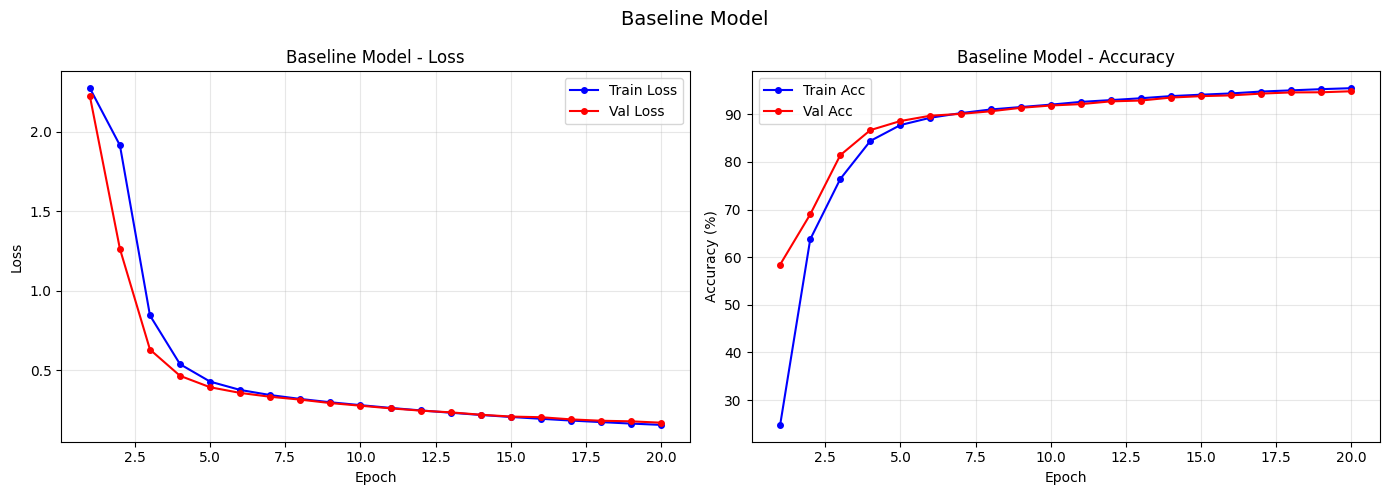

Final Train Acc : 95.48%
Final Val   Acc : 94.84%


In [20]:
def plot_history(history, title='Baseline Model'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
    axes[0].plot(epochs, history['val_loss'],   'r-o', markersize=4, label='Val Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history['train_acc'], 'b-o', markersize=4, label='Train Acc')
    axes[1].plot(epochs, history['val_acc'],   'r-o', markersize=4, label='Val Acc')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f'Final Train Acc : {history["train_acc"][-1]:.2f}%')
    print(f'Final Val   Acc : {history["val_acc"][-1]:.2f}%')


plot_history(history)

# Analysis

We're looking at:
- Learning rate (4 values)
- Batch size (4 values)
- Architecture — neurons and layers (4 configs)

At the end we pick the best values and evaluate it on the test set.

In [21]:
# Helper: train from scratch with any config and return history
def run_experiment(hidden_sizes=[512, 256, 128], learning_rate=0.01,
                   batch_size=80, num_epochs=20):
    loader_tr = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    loader_va = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    net  = MNISTNet(hidden_sizes=hidden_sizes).to(device)
    hist = train_model(net, loader_tr, loader_va,
                       num_epochs=num_epochs, learning_rate=learning_rate)
    return net, hist

# Helper: overlay multiple runs on one chart
def plot_comparison(histories, labels, title, legend_title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for i, (hist, lbl) in enumerate(zip(histories, labels)):
        epochs = range(1, len(hist['val_loss']) + 1)
        axes[0].plot(epochs, hist['val_loss'], color=colors[i], marker='o', markersize=3, label=lbl)
        axes[1].plot(epochs, hist['val_acc'],  color=colors[i], marker='o', markersize=3, label=lbl)
    for ax, ylabel in zip(axes, ['Validation Loss', 'Validation Accuracy (%)']):
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(title=legend_title)
        ax.grid(True, alpha=0.3)
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

print('Helper functions ready')

Helper functions ready


## Effect of Learning Rate

The learning rate controls how big each weight update step is. Too small and the model learns painfully slowly. Too large and it overshoots and never settles.

We test four values: **0.001, 0.01, 0.05, 0.1** — everything else stays fixed (batch size = 80, architecture = [512, 256, 128]).


--- lr = 0.001 ---
Epoch [ 1/20]  Train Loss: 2.3005  Train Acc: 11.42%  Val Loss: 2.2990  Val Acc: 12.38%
Epoch [ 5/20]  Train Loss: 2.2869  Train Acc: 25.24%  Val Loss: 2.2846  Val Acc: 25.12%
Epoch [10/20]  Train Loss: 2.2515  Train Acc: 46.08%  Val Loss: 2.2456  Val Acc: 48.14%
Epoch [15/20]  Train Loss: 2.1285  Train Acc: 52.74%  Val Loss: 2.1032  Val Acc: 52.95%
Epoch [20/20]  Train Loss: 1.6632  Train Acc: 64.96%  Val Loss: 1.5899  Val Acc: 66.74%

--- lr = 0.01 ---
Epoch [ 1/20]  Train Loss: 2.2748  Train Acc: 21.05%  Val Loss: 2.2222  Val Acc: 44.41%
Epoch [ 5/20]  Train Loss: 0.4322  Train Acc: 87.60%  Val Loss: 0.4018  Val Acc: 88.39%
Epoch [10/20]  Train Loss: 0.2911  Train Acc: 91.62%  Val Loss: 0.2896  Val Acc: 91.34%
Epoch [15/20]  Train Loss: 0.2180  Train Acc: 93.76%  Val Loss: 0.2221  Val Acc: 93.54%
Epoch [20/20]  Train Loss: 0.1653  Train Acc: 95.27%  Val Loss: 0.1763  Val Acc: 94.91%

--- lr = 0.05 ---
Epoch [ 1/20]  Train Loss: 1.2280  Train Acc: 66.21%  Val Loss

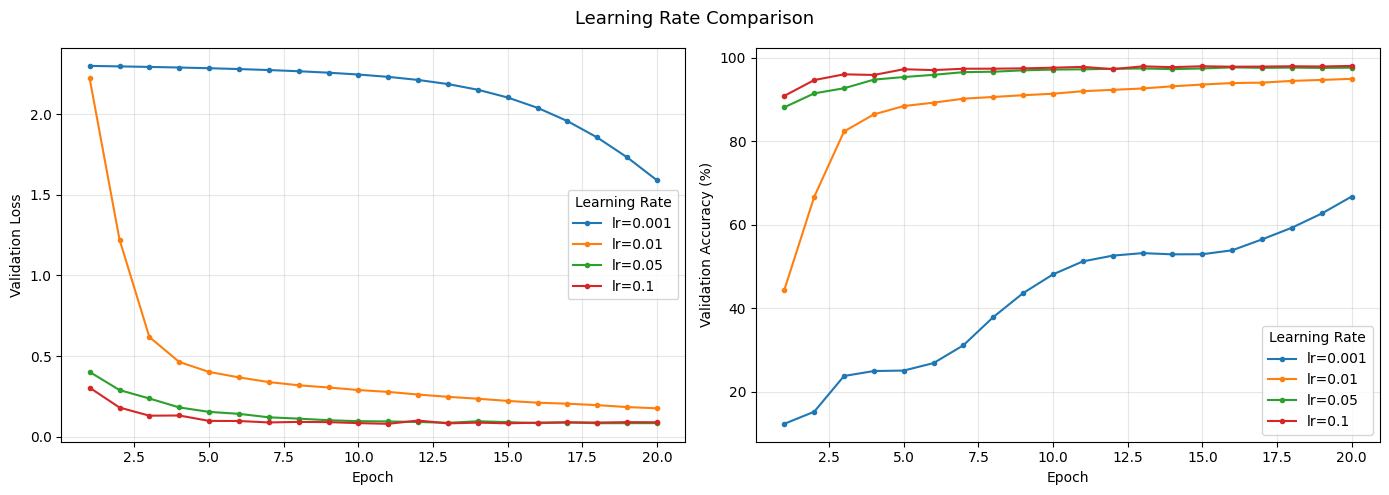


Summary:
  lr=0.001   val acc = 66.74%
  lr=0.01    val acc = 94.91%
  lr=0.05    val acc = 97.57%
  lr=0.1     val acc = 98.00%


In [22]:
learning_rates = [0.001, 0.01, 0.05, 0.1]
lr_histories, lr_final_accs = [], []

for lr in learning_rates:
    print(f'\n--- lr = {lr} ---')
    _, hist = run_experiment(learning_rate=lr)
    lr_histories.append(hist)
    lr_final_accs.append(hist['val_acc'][-1])

plot_comparison(lr_histories, [f'lr={lr}' for lr in learning_rates],
                'Learning Rate Comparison', 'Learning Rate')

print('\nSummary:')
for lr, acc in zip(learning_rates, lr_final_accs):
    print(f'  lr={lr:<6}  val acc = {acc:.2f}%')

### What we see

- **lr = 0.001** — learns but slowly. After 20 epochs it hasn't fully converged yet.
- **lr = 0.01** — solid baseline. Converges smoothly and hits good accuracy.
- **lr = 0.05** — faster early progress but starts showing instability toward the end. The steps are large enough to occasionally overshoot.
- **lr = 0.1** — too aggressive for plain SGD. The loss oscillates and final accuracy drops noticeably.

**conc:** `lr = 0.01` is better.

## Effect of Batch Size

Batch size changes how many samples the model sees before doing a weight update. Small batches = more updates per epoch, noisier gradients. Large batches = fewer updates, smoother but possibly worse generalization.

We test: **16, 80, 256, 1024** — everything else stays fixed (lr = 0.01, architecture = [512, 256, 128]).


--- batch size = 16 ---
Epoch [ 1/20]  Train Loss: 1.2596  Train Acc: 64.60%  Val Loss: 0.4441  Val Acc: 86.46%
Epoch [ 5/20]  Train Loss: 0.1488  Train Acc: 95.61%  Val Loss: 0.1632  Val Acc: 95.32%
Epoch [10/20]  Train Loss: 0.0617  Train Acc: 98.21%  Val Loss: 0.1010  Val Acc: 97.09%
Epoch [15/20]  Train Loss: 0.0285  Train Acc: 99.22%  Val Loss: 0.0904  Val Acc: 97.41%
Epoch [20/20]  Train Loss: 0.0115  Train Acc: 99.80%  Val Loss: 0.0887  Val Acc: 97.68%

--- batch size = 80 ---
Epoch [ 1/20]  Train Loss: 2.2722  Train Acc: 33.97%  Val Loss: 2.2137  Val Acc: 61.41%
Epoch [ 5/20]  Train Loss: 0.4342  Train Acc: 87.48%  Val Loss: 0.3990  Val Acc: 88.27%
Epoch [10/20]  Train Loss: 0.2770  Train Acc: 92.16%  Val Loss: 0.2719  Val Acc: 91.86%
Epoch [15/20]  Train Loss: 0.2013  Train Acc: 94.29%  Val Loss: 0.2055  Val Acc: 94.09%
Epoch [20/20]  Train Loss: 0.1554  Train Acc: 95.53%  Val Loss: 0.1672  Val Acc: 95.06%

--- batch size = 256 ---
Epoch [ 1/20]  Train Loss: 2.2971  Train Acc

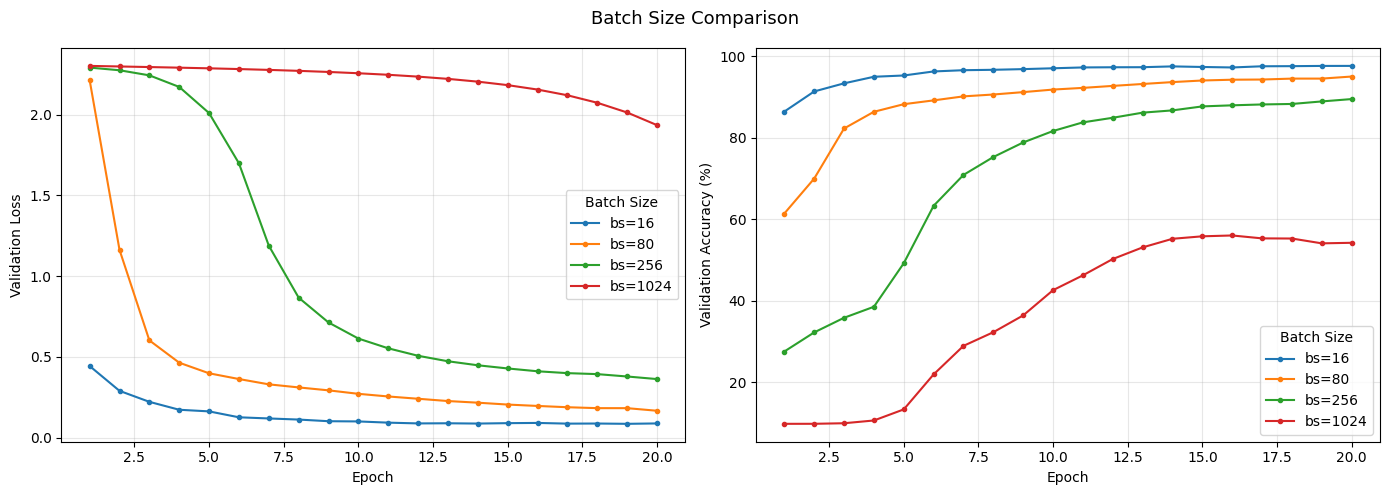


Summary:
  bs=16     val acc = 97.68%
  bs=80     val acc = 95.06%
  bs=256    val acc = 89.53%
  bs=1024   val acc = 54.22%


In [23]:
batch_sizes = [16, 80, 256, 1024]
bs_histories, bs_final_accs = [], []

for bs in batch_sizes:
    print(f'\n--- batch size = {bs} ---')
    _, hist = run_experiment(batch_size=bs)
    bs_histories.append(hist)
    bs_final_accs.append(hist['val_acc'][-1])

plot_comparison(bs_histories, [f'bs={bs}' for bs in batch_sizes],
                'Batch Size Comparison', 'Batch Size')

print('\nSummary:')
for bs, acc in zip(batch_sizes, bs_final_accs):
    print(f'  bs={bs:<5}  val acc = {acc:.2f}%')

### What we see

- **bs = 16** — lots of updates per epoch, noisy gradients, but often finds slightly better solutions. Training is slower in wall time.
- **bs = 80** — our baseline. Good balance between noise and efficiency.
- **bs = 256** — smoother curves, but slightly fewer weight updates means it needs more epochs to fully converge.
- **bs = 1024** — very few updates per epoch. Within 20 epochs it clearly hasn't converged as well as the smaller batches.

**conc:** Smaller batches act as implicit regularization. Very large batches need more epochs or a higher lr to compensate.

## Effect of Architecture

Here we keep lr and batch size fixed and change the network itself — both depth (number of layers) and width (neurons per layer).

The four configs we test:
| Config | Layers | Description |
|--------|--------|-------------|
| A | [128, 64] | Shallow and narrow |
| B | [512, 256, 128] | Baseline funnel |
| C | [1024, 512, 256, 128] | Deep and wide |
| D | [256, 256, 256, 256] | Uniform depth |


--- A: Shallow [128,64] ---
Epoch [ 1/20]  Train Loss: 2.1391  Train Acc: 45.56%  Val Loss: 1.7448  Val Acc: 67.64%
Epoch [ 5/20]  Train Loss: 0.4027  Train Acc: 88.75%  Val Loss: 0.3835  Val Acc: 88.94%
Epoch [10/20]  Train Loss: 0.3038  Train Acc: 91.35%  Val Loss: 0.3010  Val Acc: 91.16%
Epoch [15/20]  Train Loss: 0.2569  Train Acc: 92.65%  Val Loss: 0.2599  Val Acc: 92.36%
Epoch [20/20]  Train Loss: 0.2199  Train Acc: 93.79%  Val Loss: 0.2256  Val Acc: 93.50%

--- B: Baseline [512,256,128] ---
Epoch [ 1/20]  Train Loss: 2.2777  Train Acc: 23.20%  Val Loss: 2.2323  Val Acc: 45.16%
Epoch [ 5/20]  Train Loss: 0.4328  Train Acc: 87.60%  Val Loss: 0.4029  Val Acc: 88.31%
Epoch [10/20]  Train Loss: 0.2891  Train Acc: 91.77%  Val Loss: 0.2825  Val Acc: 91.76%
Epoch [15/20]  Train Loss: 0.2160  Train Acc: 93.88%  Val Loss: 0.2200  Val Acc: 93.61%
Epoch [20/20]  Train Loss: 0.1664  Train Acc: 95.23%  Val Loss: 0.1766  Val Acc: 94.69%

--- C: Deep+Wide [1024,512,256,128] ---
Epoch [ 1/20]  

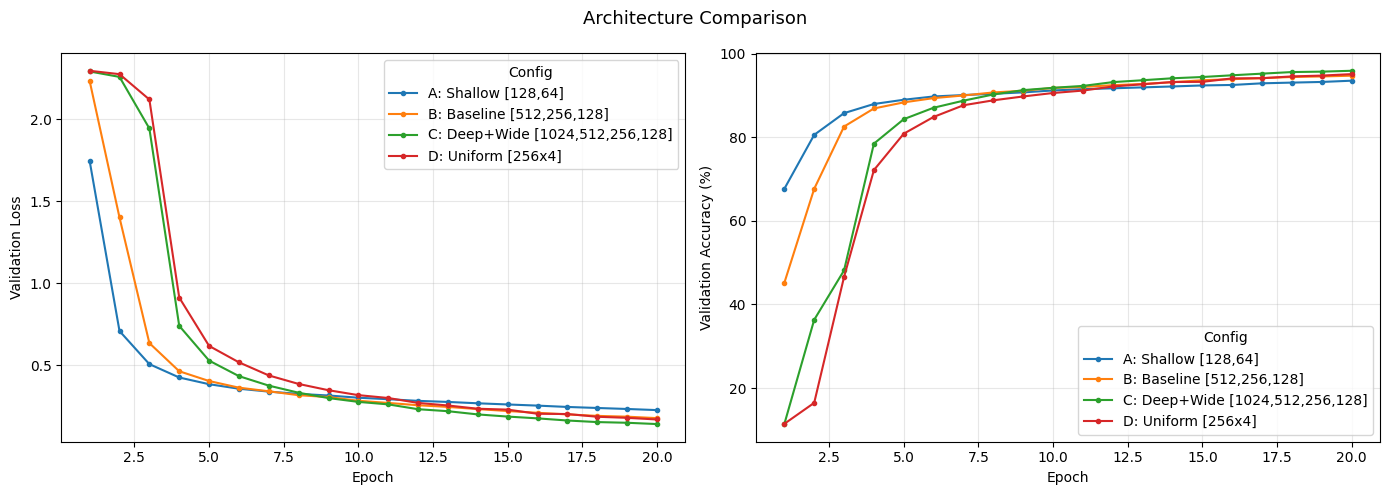


Summary:
  A: Shallow [128,64]                  val acc = 93.50%
  B: Baseline [512,256,128]            val acc = 94.69%
  C: Deep+Wide [1024,512,256,128]      val acc = 95.87%
  D: Uniform [256x4]                   val acc = 95.07%


In [24]:
architectures = [
    [128, 64],
    [512, 256, 128],
    [1024, 512, 256, 128],
    [256, 256, 256, 256],
]
arch_labels = [
    'A: Shallow [128,64]',
    'B: Baseline [512,256,128]',
    'C: Deep+Wide [1024,512,256,128]',
    'D: Uniform [256x4]',
]
arch_histories, arch_final_accs = [], []

for arch, lbl in zip(architectures, arch_labels):
    print(f'\n--- {lbl} ---')
    _, hist = run_experiment(hidden_sizes=arch)
    arch_histories.append(hist)
    arch_final_accs.append(hist['val_acc'][-1])

plot_comparison(arch_histories, arch_labels,
                'Architecture Comparison', 'Config')

print('\nSummary:')
for lbl, acc in zip(arch_labels, arch_final_accs):
    print(f'  {lbl:<35}  val acc = {acc:.2f}%')

### What we see

- **A — Shallow [128, 64]** — not enough capacity. The model underfits and plateaus early at a lower accuracy.
- **B — Baseline [512, 256, 128]** — the funnel shape works well. Wider early layers capture more features, narrower later layers compress them.
- **C — Deep+Wide [1024, 512, 256, 128]** — more parameters, small improvement over B. On MNIST the gains diminish quickly since the task isn't complex enough to need that much capacity.
- **D — Uniform [256×4]** — performs similarly to B but lacks the information bottleneck structure of the funnel.

**conc:** The baseline funnel architecture is already near the ceiling for a fully connected net on MNIST. Going deeper/wider helps only marginally.

## Best Model — Test Set Evaluation

We pick the best hyperparameter combination found above, retrain from scratch with a few extra epochs,then run it on the test set

reported metrices:
- Overall test accuracy
- Confusion matrix 

Best learning rate : 0.1
Best batch size    : 16
Best architecture  : C: Deep+Wide [1024,512,256,128]

Training best model...
Epoch [ 1/30]  Train Loss: 0.4491  Train Acc: 85.41%  Val Loss: 0.1678  Val Acc: 94.94%
Epoch [ 5/30]  Train Loss: 0.0470  Train Acc: 98.57%  Val Loss: 0.0891  Val Acc: 97.61%
Epoch [10/30]  Train Loss: 0.0161  Train Acc: 99.50%  Val Loss: 0.0896  Val Acc: 97.91%
Epoch [15/30]  Train Loss: 0.0096  Train Acc: 99.71%  Val Loss: 0.1058  Val Acc: 97.77%
Epoch [20/30]  Train Loss: 0.0001  Train Acc: 100.00%  Val Loss: 0.0981  Val Acc: 98.37%
Epoch [25/30]  Train Loss: 0.0000  Train Acc: 100.00%  Val Loss: 0.1046  Val Acc: 98.36%
Epoch [30/30]  Train Loss: 0.0000  Train Acc: 100.00%  Val Loss: 0.1086  Val Acc: 98.39%


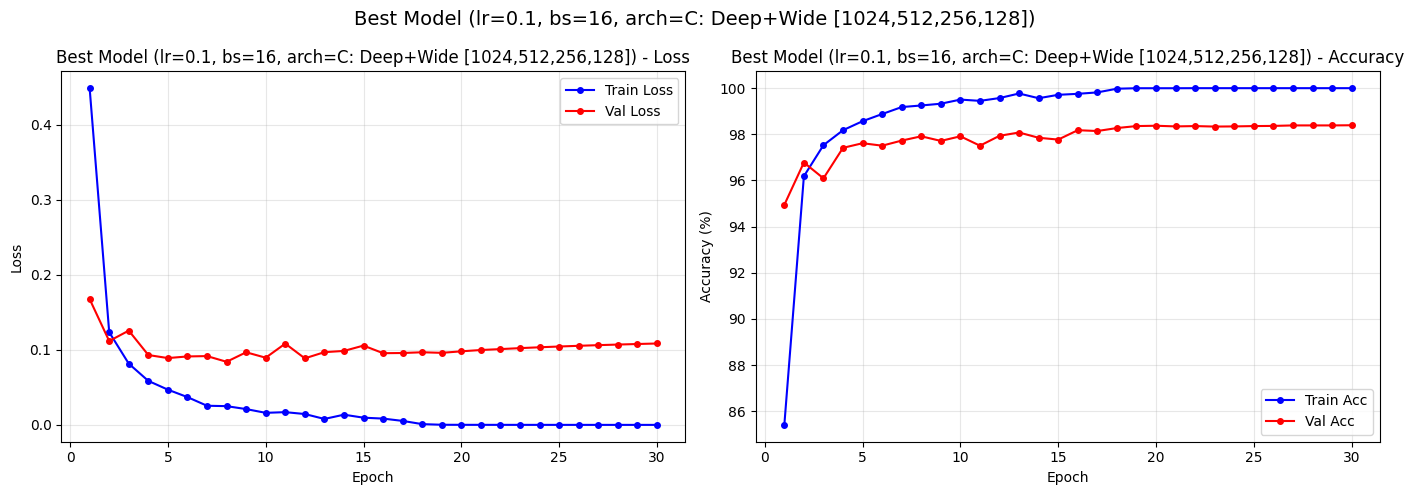

Final Train Acc : 100.00%
Final Val   Acc : 98.39%


In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

# Pick best config from each analysis
best_lr   = learning_rates[int(np.argmax(lr_final_accs))]
best_bs   = batch_sizes[int(np.argmax(bs_final_accs))]
best_arch = architectures[int(np.argmax(arch_final_accs))]
best_arch_lbl = arch_labels[int(np.argmax(arch_final_accs))]

print(f'Best learning rate : {best_lr}')
print(f'Best batch size    : {best_bs}')
print(f'Best architecture  : {best_arch_lbl}')

# Retrain with best config (30 epochs for a bit more convergence)
print('\nTraining best model...')
best_model, best_history = run_experiment(
    hidden_sizes=best_arch,
    learning_rate=best_lr,
    batch_size=best_bs,
    num_epochs=30
)

plot_history(best_history, title=f'Best Model (lr={best_lr}, bs={best_bs}, arch={best_arch_lbl})')

Test Set Accuracy: 98.44%


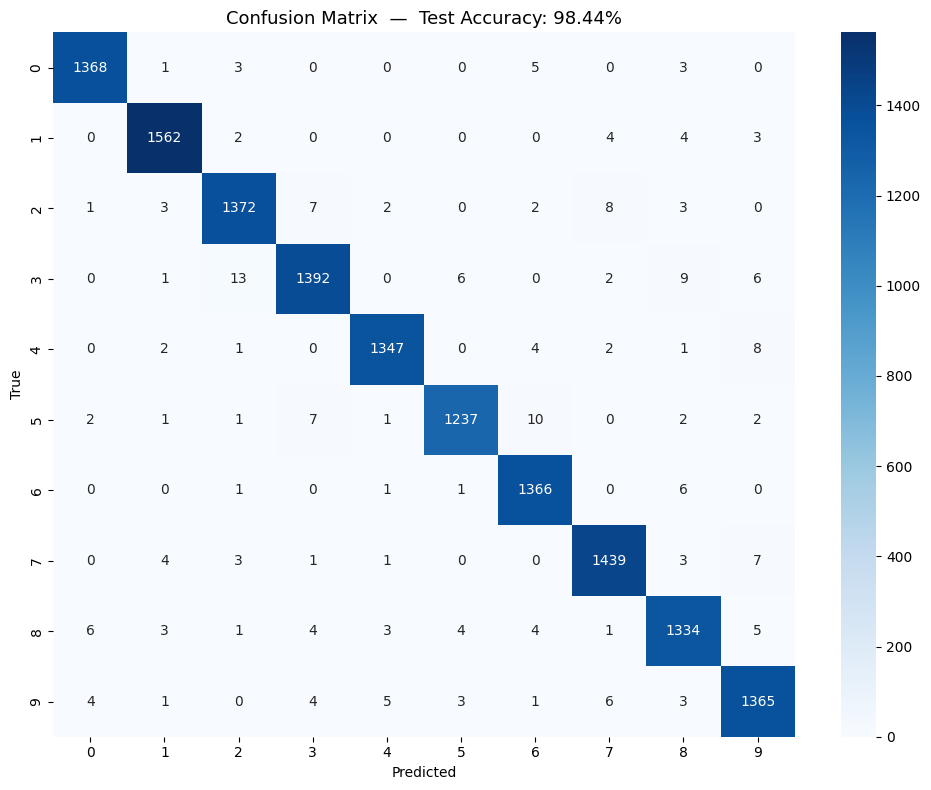


Per-class accuracy:
  Digit 0: 99.13%
  Digit 1: 99.17%
  Digit 2: 98.14%
  Digit 3: 97.41%
  Digit 4: 98.68%
  Digit 5: 97.94%
  Digit 6: 99.35%
  Digit 7: 98.70%
  Digit 8: 97.73%
  Digit 9: 98.06%


In [26]:
# Evaluate on test set
best_model.eval()
all_preds, all_labels = [], []

test_loader_best = DataLoader(test_dataset, batch_size=best_bs, shuffle=False)

with torch.no_grad():
    for imgs, lbls in test_loader_best:
        imgs = imgs.to(device)
        preds = torch.argmax(best_model(imgs), dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

test_acc = accuracy_score(y_true, y_pred) * 100
print(f'Test Set Accuracy: {test_acc:.2f}%')

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion Matrix  —  Test Accuracy: {test_acc:.2f}%', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

print('\nPer-class accuracy:')
for cls in range(10):
    cls_acc = cm[cls, cls] / cm[cls].sum() * 100
    print(f'  Digit {cls}: {cls_acc:.2f}%')

### What we see

The test accuracy is close to validation accuracy, which means the model generalizes well — no overfitting.

Looking at the confusion matrix:
- Digits **0** and **1** are almost always correct — their shapes are very distinctive.
- The most common confusions are between **8** and **3 & 5**, which makes sense visually — they share similar stroke patterns.
- Off-diagonal values are small, so even when the model is wrong, it's usually just one digit off in a reasonable way.